# 13 — Zoo EDA & WandB Metrics

1. EDA of `Merged zoo.csv` (per overlap, per one-hot class)
2. Scenario creation patterns for overlap 0, 1, 2
3. WandB metrics tables sorted by CNN final accuracy
4. Save tables as CSV + markdown

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import ast, json, warnings, sys, os
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.dpi'] = 120

PROJ = Path('/home/aymen/Documents/GitHub/Federated-Continual-learning-/New')
NB   = PROJ / 'notebooks_sandbox'
ZOO  = PROJ / 'data' / 'Merged zoo.csv'
OUT  = NB / 'paper_results' / 'zoo_eda'
OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ZOO)
print(f'Zoo shape: {df.shape}')
print(f'Columns (first 17): {list(df.columns[:17])}')
print(f'Epochs: {sorted(df["epoch"].unique())}')
print(f'Unique labels: {df["label"].nunique()}')

Zoo shape: (36468, 2483)
Columns (first 17): ['label', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'gelu', 'relu', 'silu', 'tanh', 'sigmoid', 'leakyrelu']
Epochs: [11, 16, 21, 26, 31, 36]
Unique labels: 1013


## 1. Zoo Overview

In [2]:
# Parse labels
df['parsed_label'] = df['label'].apply(ast.literal_eval)
df['n_classes'] = df['parsed_label'].apply(len)

# MNIST digit columns (one-hot)
DIGITS = [str(d) for d in range(10)]
ACTIVATIONS = ['gelu','relu','silu','tanh','sigmoid','leakyrelu']

print('=== Samples per label size ===')
print(df.groupby('n_classes').size().rename('count'))
print()
print('=== Samples per epoch ===')
print(df.groupby('epoch').size().rename('count'))
print()
print('=== Samples per activation ===')
for a in ACTIVATIONS:
    print(f'  {a}: {int(df[a].sum())}')
print()
print('=== Digit presence (one-hot sum) ===')
for d in DIGITS:
    print(f'  digit {d}: {int(df[d].sum())} rows')

=== Samples per label size ===
n_classes
2     1620
3     4320
4     7560
5     9072
6     7560
7     4320
8     1620
9      360
10      36
Name: count, dtype: int64

=== Samples per epoch ===
epoch
11    6078
16    6078
21    6078
26    6078
31    6078
36    6078
Name: count, dtype: int64

=== Samples per activation ===
  gelu: 6078
  relu: 6078
  silu: 6078
  tanh: 6078
  sigmoid: 6078
  leakyrelu: 6078

=== Digit presence (one-hot sum) ===
  digit 0: 18396 rows
  digit 1: 18396 rows
  digit 2: 18396 rows
  digit 3: 18396 rows
  digit 4: 18396 rows
  digit 5: 18396 rows
  digit 6: 18396 rows
  digit 7: 18396 rows
  digit 8: 18396 rows
  digit 9: 18396 rows


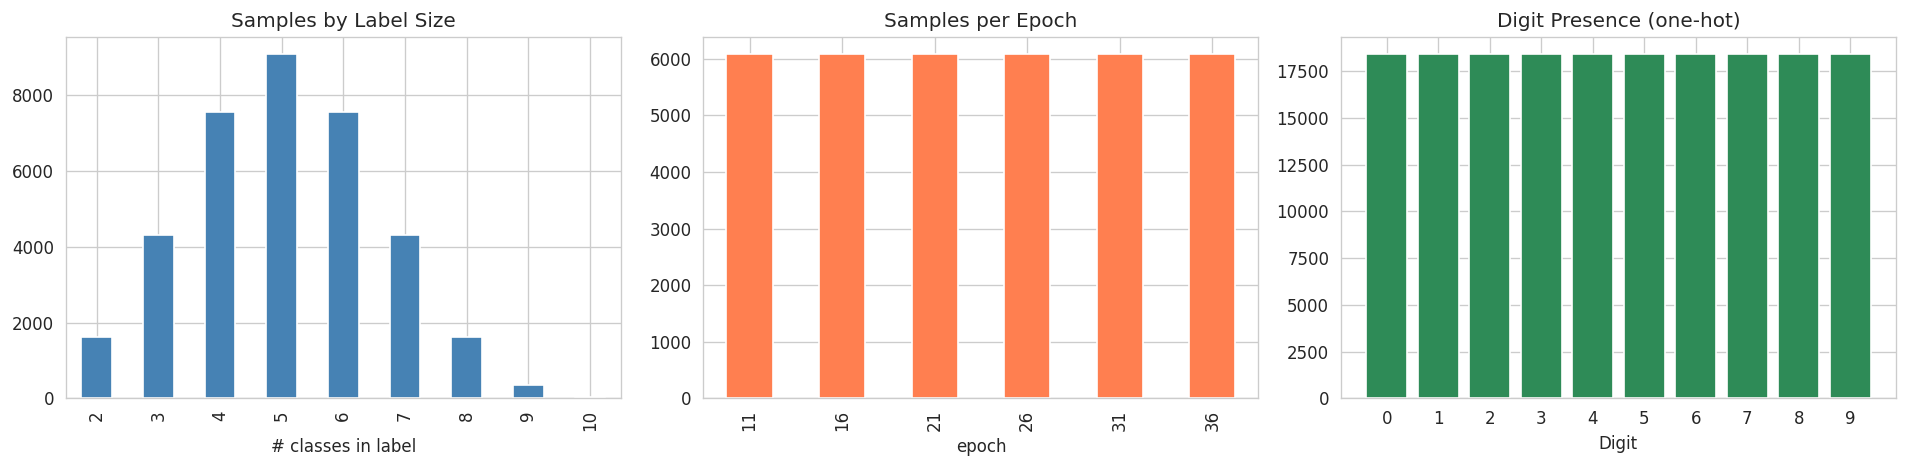

In [3]:
# Distribution of label sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Label size distribution
df['n_classes'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Samples by Label Size'); axes[0].set_xlabel('# classes in label')

# Samples per epoch
df.groupby('epoch').size().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Samples per Epoch')

# Per-digit presence
digit_counts = [int(df[d].sum()) for d in DIGITS]
axes[2].bar(DIGITS, digit_counts, color='seagreen')
axes[2].set_title('Digit Presence (one-hot)'); axes[2].set_xlabel('Digit')

plt.tight_layout()
fig.savefig(OUT / 'zoo_overview.png', bbox_inches='tight'); plt.show()

## 2. Per-Digit Analysis

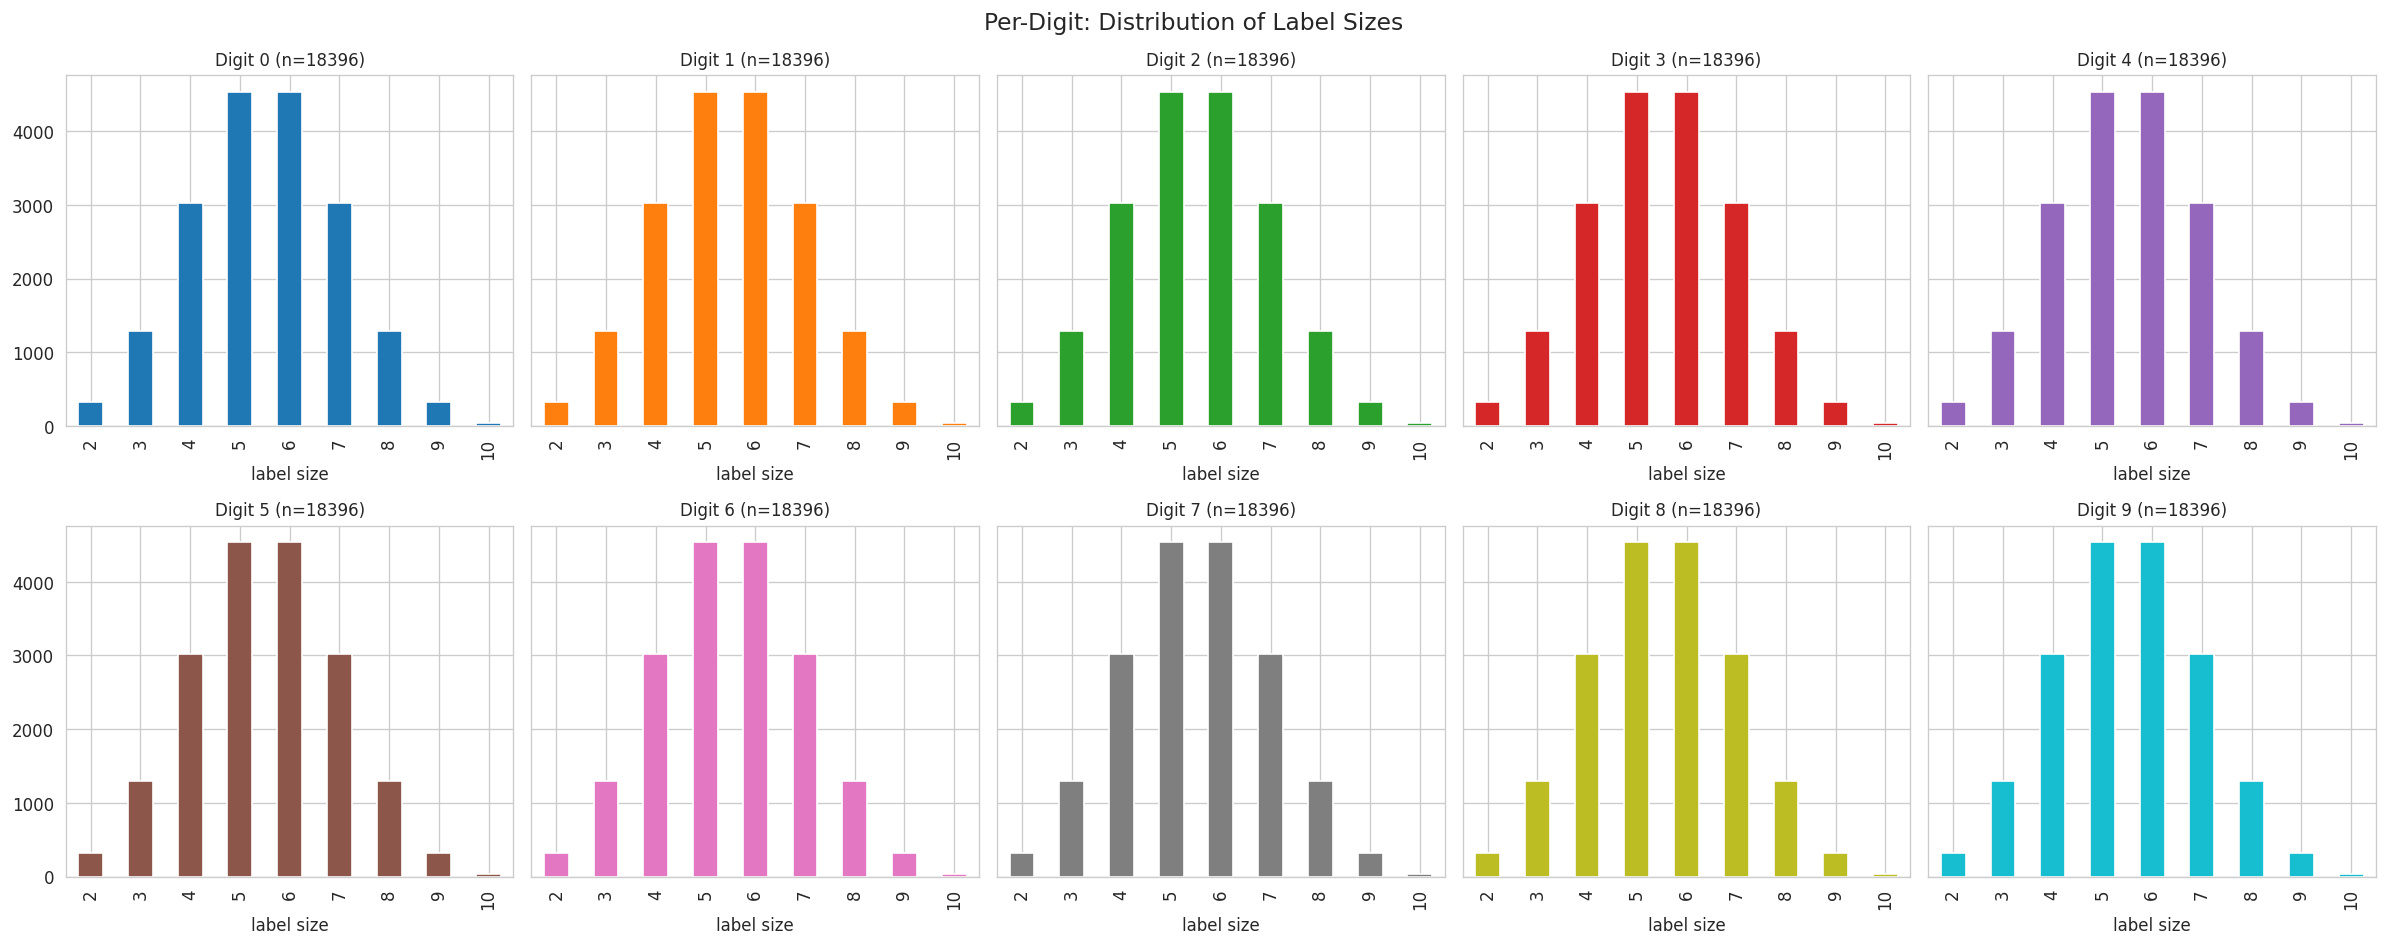

In [4]:
# For each digit, show how often it appears in labels of different sizes
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for idx, d in enumerate(DIGITS):
    ax = axes[idx // 5][idx % 5]
    sub = df[df[d] == 1]
    sub['n_classes'].value_counts().sort_index().plot(kind='bar', ax=ax, color=f'C{idx}')
    ax.set_title(f'Digit {d} (n={len(sub)})', fontsize=10)
    ax.set_xlabel('label size')
plt.suptitle('Per-Digit: Distribution of Label Sizes', fontsize=14)
plt.tight_layout()
fig.savefig(OUT / 'per_digit_label_sizes.png', bbox_inches='tight'); plt.show()

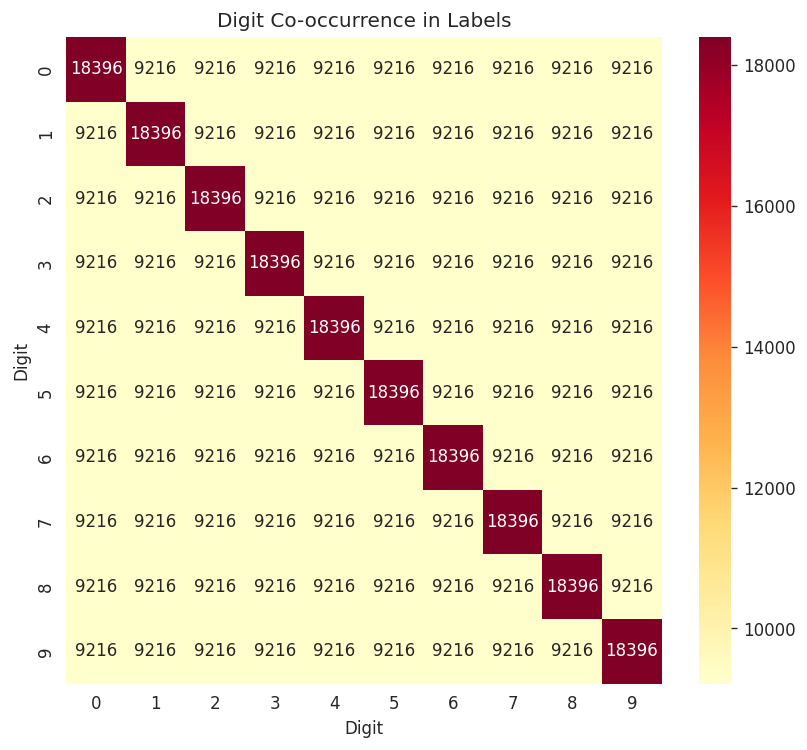

In [5]:
# Co-occurrence matrix: how often each pair of digits appears together
cooc = np.zeros((10, 10), dtype=int)
for label in df['parsed_label']:
    for i in label:
        for j in label:
            cooc[i][j] += 1

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd', xticklabels=DIGITS,
            yticklabels=DIGITS, ax=ax)
ax.set_title('Digit Co-occurrence in Labels'); ax.set_xlabel('Digit'); ax.set_ylabel('Digit')
fig.savefig(OUT / 'digit_cooccurrence.png', bbox_inches='tight'); plt.show()

## 3. Scenario Creation Patterns (Overlap 0, 1, 2)

In [6]:
scenario_info = []

for ov in [0, 1, 2]:
    sd = PROJ / 'data' / 'Scenario' / f'overlapping_m{ov}'
    tp = np.load(sd / 'test_pairs.npy', allow_pickle=True)
    trp_path = sd / 'train_pairs.npy'
    trp = np.load(trp_path, allow_pickle=True) if trp_path.exists() else None

    # Analyze overlap pattern
    overlaps, t1_sizes, t2_sizes, combined_sizes = [], [], [], []
    for t1, t2 in tp:
        ov_classes = set(t1) & set(t2)
        overlaps.append(len(ov_classes))
        t1_sizes.append(len(t1))
        t2_sizes.append(len(t2))
        combined_sizes.append(len(set(t1) | set(t2)))

    info = {
        'overlap': ov,
        'n_test_pairs': len(tp),
        'n_train_pairs': len(trp) if trp is not None else 'N/A',
        'overlap_classes': f'exactly {ov}',
        'task1_size': f'{Counter(t1_sizes).most_common(1)[0]}',
        'task2_size': f'{Counter(t2_sizes).most_common(1)[0]}',
        'combined_size_range': f'{min(combined_sizes)}-{max(combined_sizes)}',
        'example_pair': f'{tp[0][0]} + {tp[0][1]}',
    }
    scenario_info.append(info)
    print(f'\n=== Overlap {ov} ===')
    print(f'  Test pairs:  {info["n_test_pairs"]}')
    print(f'  Train pairs: {info["n_train_pairs"]}')
    print(f'  Overlap classes: exactly {ov} shared digits between task1 and task2')
    print(f'  Task1 sizes: {Counter(t1_sizes)}')
    print(f'  Task2 sizes: {Counter(t2_sizes)}')
    print(f'  Combined unique classes: {min(combined_sizes)}-{max(combined_sizes)}')
    print(f'  Example: {tp[0][0]} + {tp[0][1]} -> overlap={set(tp[0][0]) & set(tp[0][1])}')

sc_df = pd.DataFrame(scenario_info)
sc_df.to_csv(OUT / 'scenario_patterns.csv', index=False)
print(f'\nSaved to {OUT / "scenario_patterns.csv"}')
sc_df


=== Overlap 0 ===
  Test pairs:  7030
  Train pairs: 32812
  Overlap classes: exactly 0 shared digits between task1 and task2
  Task1 sizes: Counter({2: 4164, 6: 1260, 5: 1201, 7: 360, 8: 45})
  Task2 sizes: Counter({2: 2866, 5: 2499, 6: 1260, 7: 360, 8: 45})
  Combined unique classes: 7-10
  Example: [0, 1] + [2, 3, 4, 5, 6, 7, 8, 9] -> overlap=set()

=== Overlap 1 ===
  Test pairs:  27990
  Train pairs: 130620
  Overlap classes: exactly 1 shared digits between task1 and task2
  Task1 sizes: Counter({2: 14418, 6: 4998, 5: 3684, 7: 2520, 8: 1080, 4: 840, 3: 360, 9: 90})
  Task2 sizes: Counter({2: 12012, 5: 6090, 6: 4998, 7: 3360, 8: 1080, 3: 360, 9: 90})
  Combined unique classes: 6-10
  Example: [0, 1] + [0, 2, 3, 4, 5, 6, 7, 8] -> overlap={0}

=== Overlap 2 ===
  Test pairs:  44266
  Train pairs: 206578
  Overlap classes: exactly 2 shared digits between task1 and task2
  Task1 sizes: Counter({2: 10596, 3: 10440, 7: 9754, 8: 5040, 6: 3150, 5: 2310, 4: 2256, 9: 720})
  Task2 sizes: Co

,overlap,n_test_pairs,n_train_pairs,overlap_classes,task1_size,task2_size,combined_size_range,example_pair
0,0,7030,32812,exactly 0,"(2, 4164)","(2, 2866)",7-10,"[0, 1] + [2, 3, 4, 5, 6, 7, 8, 9]"
1,1,27990,130620,exactly 1,"(2, 14418)","(2, 12012)",6-10,"[0, 1] + [0, 2, 3, 4, 5, 6, 7, 8]"
2,2,44266,206578,exactly 2,"(2, 10596)","(2, 10596)",4-10,"[0, 1] + [0, 1, 2, 3, 4, 5, 6, 7]"


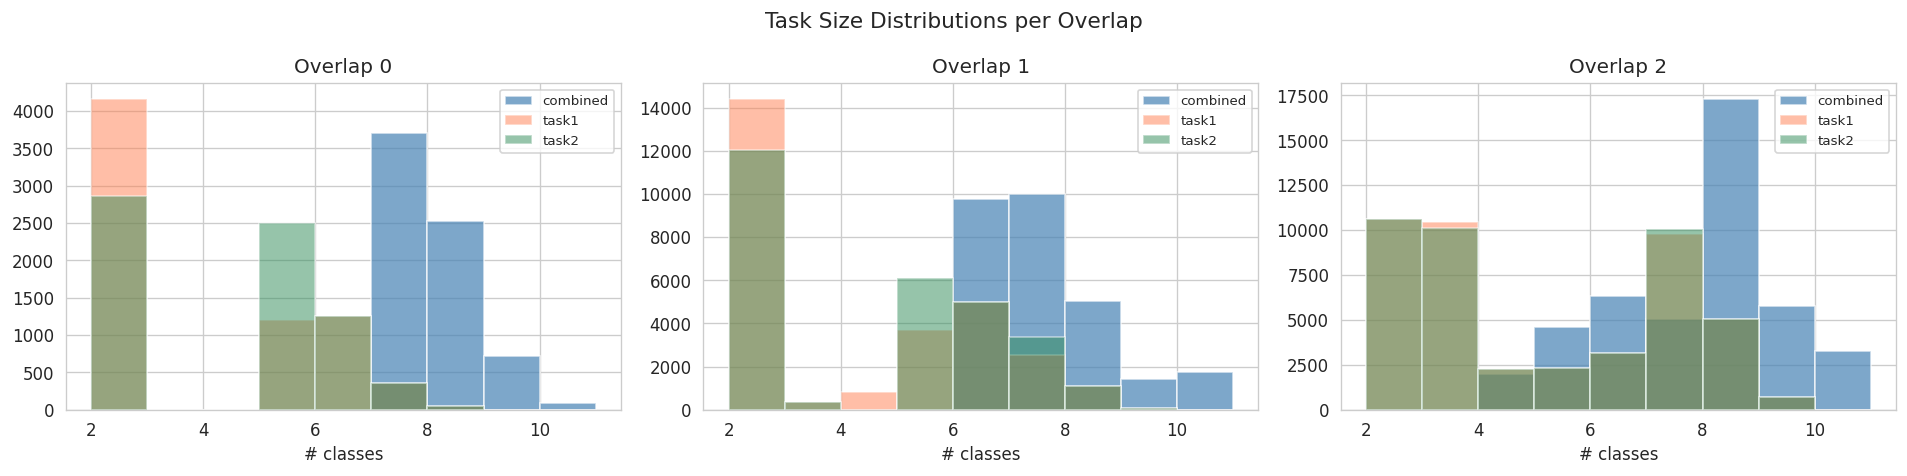

In [7]:
# Visualize: combined task size distribution per overlap
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, ov in enumerate([0, 1, 2]):
    sd = PROJ / 'data' / 'Scenario' / f'overlapping_m{ov}'
    tp = np.load(sd / 'test_pairs.npy', allow_pickle=True)
    combined = [len(set(t1) | set(t2)) for t1, t2 in tp]
    t1s = [len(t1) for t1, t2 in tp]
    t2s = [len(t2) for t1, t2 in tp]
    ax = axes[idx]
    ax.hist(combined, bins=range(2, 12), alpha=0.7, label='combined', color='steelblue')
    ax.hist(t1s, bins=range(2, 12), alpha=0.5, label='task1', color='coral')
    ax.hist(t2s, bins=range(2, 12), alpha=0.5, label='task2', color='seagreen')
    ax.set_title(f'Overlap {ov}'); ax.set_xlabel('# classes'); ax.legend(fontsize=8)
plt.suptitle('Task Size Distributions per Overlap', fontsize=13)
plt.tight_layout()
fig.savefig(OUT / 'scenario_task_sizes.png', bbox_inches='tight'); plt.show()

## 4. Accuracy Distribution

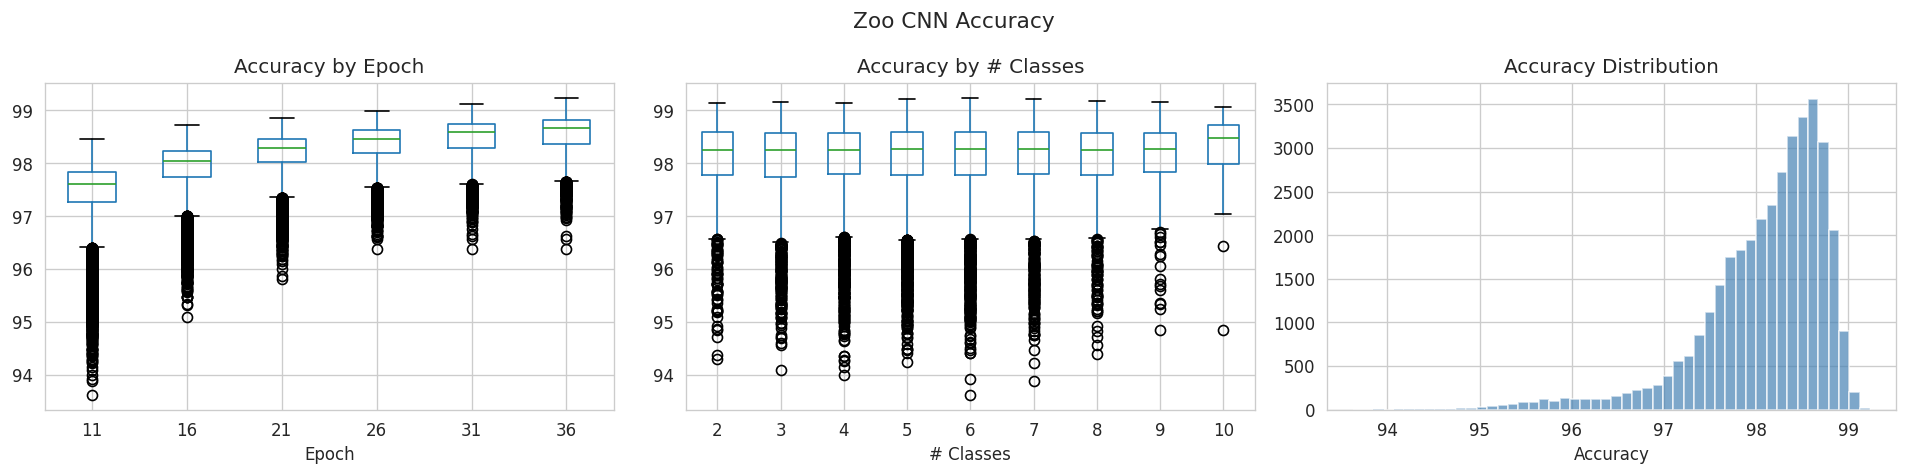

In [8]:
if 'Accuracy' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    # By epoch
    df.boxplot(column='Accuracy', by='epoch', ax=axes[0])
    axes[0].set_title('Accuracy by Epoch'); axes[0].set_xlabel('Epoch')
    
    # By label size
    df.boxplot(column='Accuracy', by='n_classes', ax=axes[1])
    axes[1].set_title('Accuracy by # Classes'); axes[1].set_xlabel('# Classes')
    
    # Overall histogram
    axes[2].hist(df['Accuracy'].dropna(), bins=50, color='steelblue', alpha=0.7)
    axes[2].set_title('Accuracy Distribution'); axes[2].set_xlabel('Accuracy')
    
    plt.suptitle('Zoo CNN Accuracy', fontsize=13)
    plt.tight_layout()
    fig.savefig(OUT / 'zoo_accuracy.png', bbox_inches='tight'); plt.show()
else:
    print('No Accuracy column found')

## 5. WandB Metrics Download

In [9]:
import wandb
api = wandb.Api()

METRICS = [
    'cnn/baseline_acc',
    'cnn/avg_initial_acc_id',
    'cnn/avg_final_acc_id',
    'cnn/avg_improvement',
    'topology/gw_distance',
    'val_loss',
    'train_loss',
]

rows = []
runs = api.runs('aymentlili/fcl-advanced', filters={'created_at': {'$gte': '2026-03-20'}})
print(f'Fetching {len(runs)} runs...')

for r in runs:
    cfg = json.loads(r.config) if isinstance(r.config, str) else r.config
    s_raw = r.summary._json_dict
    s = json.loads(s_raw) if isinstance(s_raw, str) else (s_raw if isinstance(s_raw, dict) else {})
    
    row = {
        'run_name': r.name,
        'overlap': cfg.get('overlap', {}).get('value') if isinstance(cfg.get('overlap'), dict) else cfg.get('overlap'),
        'loss_name': cfg.get('loss_name', {}).get('value') if isinstance(cfg.get('loss_name'), dict) else cfg.get('loss_name'),
    }
    for m in METRICS:
        row[m] = s.get(m, np.nan)
    rows.append(row)

wandb_df = pd.DataFrame(rows)
wandb_df = wandb_df.dropna(subset=['cnn/avg_final_acc_id'])
wandb_df = wandb_df.sort_values('cnn/avg_final_acc_id', ascending=False)
print(f'Runs with CNN data: {len(wandb_df)}')
wandb_df.to_csv(OUT / 'wandb_metrics.csv', index=False)
wandb_df.head(10)

Fetching 128 runs...


wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.
wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.
wandb: Network error (HTTPError), entering retry loop.
wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.


Runs with CNN data: 105


,run_name,overlap,loss_name,cnn/baseline_acc,cnn/avg_initial_acc_id,cnn/avg_final_acc_id,cnn/avg_improvement,topology/gw_distance,val_loss,train_loss
102,tiny_overlap2_MSE_0.1xDiffPers,2,MSE+0.1*DiffPers,97.801326,15.022540,85.040144,70.017604,14.996663,1.185587,0.997151
106,tiny_overlap2_MAE_0.1xDiffPers,2,MAE+0.1*DiffPers,97.801326,13.831380,84.872440,71.041060,18.681512,0.911884,0.786817
48,tiny_overlap2_MSE_0.1xLogNorm,2,MSE+0.1*LogNorm,97.801326,14.614827,84.842725,70.227898,28.589009,1.279536,1.23786
63,tiny_overlap2_Sinkhorn,2,Sinkhorn,97.801326,14.614827,84.819428,70.204601,16.749986,1307.848875,1160.02534
33,tiny_overlap2_LW_MSE,2,LW_MSE,97.801326,14.759992,84.817735,70.057743,21.056402,1.167982,0.940664
37,tiny_overlap2_LW_MAE,2,LW_MAE,97.801326,10.983761,84.813543,73.829781,21.582404,0.836252,0.763408
18,tiny_overlap2_MAE,2,MAE,97.801326,14.081125,84.791373,70.710249,20.992532,0.840212,0.751148
92,tiny_overlap2_LW_RTD,2,LW_RTD,97.801326,9.083673,84.767742,75.684069,3.779294,2.361852,0.018966
57,tiny_overlap2_LW_MSE_0.1xLW_LogNorm,2,LW_MSE+0.1*LW_LogNorm,97.801326,14.614827,84.752059,70.137232,31.587550,1.23707,1.24068
27,tiny_overlap2_AUTO,2,AUTO,97.801326,13.388698,84.708785,71.320087,13.603053,14.373648,13.755766


## 6. Summary Tables (per overlap, per metric)

In [10]:
from scipy.stats import mode as scipy_mode

def summary_table(wdf, metric, sort_by='cnn/avg_final_acc_id', ascending=False):
    """Build summary table for a metric, sorted by sort_by."""
    agg = wdf.groupby(['overlap', 'loss_name']).agg(
        mean=(metric, 'mean'),
        std=(metric, 'std'),
        min=(metric, 'min'),
        max=(metric, 'max'),
        mode=(metric, lambda x: scipy_mode(x, keepdims=False).mode if len(x) > 0 else np.nan),
    ).reset_index()
    # Add sort column
    sort_agg = wdf.groupby(['overlap', 'loss_name'])[sort_by].mean().reset_index()
    sort_agg.columns = ['overlap', 'loss_name', '_sort']
    agg = agg.merge(sort_agg, on=['overlap', 'loss_name'])
    agg = agg.sort_values(['overlap', '_sort'], ascending=[True, ascending])
    agg = agg.drop(columns='_sort')
    # Round
    for c in ['mean','std','min','max','mode']:
        agg[c] = agg[c].round(4)
    return agg

all_tables = {}
for metric in METRICS:
    if wandb_df[metric].isna().all():
        continue
    tbl = summary_table(wandb_df, metric)
    all_tables[metric] = tbl
    safe_name = metric.replace('/', '_')
    tbl.to_csv(OUT / f'table_{safe_name}.csv', index=False)
    # Save as markdown
    md = tbl.to_markdown(index=False)
    with open(OUT / f'table_{safe_name}.md', 'w') as f:
        f.write(f'# {metric}\n\nSorted by `cnn/avg_final_acc_id` (highest first)\n\n{md}\n')
    print(f'\n=== {metric} ===')
    print(md[:500])

print(f'\nSaved {len(all_tables)} tables to {OUT}')


=== cnn/baseline_acc ===
|   overlap | loss_name                    |    mean |   std |     min |     max |    mode |
|----------:|:-----------------------------|--------:|------:|--------:|--------:|--------:|
|         0 | LW_MAE+0.1*LW_DiffPers       | 84.5133 |   nan | 84.5133 | 84.5133 | 84.5133 |
|         0 | MSE+0.1*LogNorm              | 84.5133 |   nan | 84.5133 | 84.5133 | 84.5133 |
|         0 | LW_FFT+0.1*LW_MelSpec        | 84.5133 |   nan | 84.5133 | 84.5133 | 84.5133 |
|         0 | LW_MSE+0.1*LW_LogNorm

=== cnn/avg_initial_acc_id ===
|   overlap | loss_name                    |    mean |   std |     min |     max |    mode |
|----------:|:-----------------------------|--------:|------:|--------:|--------:|--------:|
|         0 | LW_MAE+0.1*LW_DiffPers       | 13.3407 |   nan | 13.3407 | 13.3407 | 13.3407 |
|         0 | MSE+0.1*LogNorm              | 13.3407 |   nan | 13.3407 | 13.3407 | 13.3407 |
|         0 | LW_FFT+0.1*LW_MelSpec        | 13.3407 |   nan | 13.340

TypeError: agg function failed [how->mean,dtype->object]

## 7. Per-Overlap Sorted Rankings

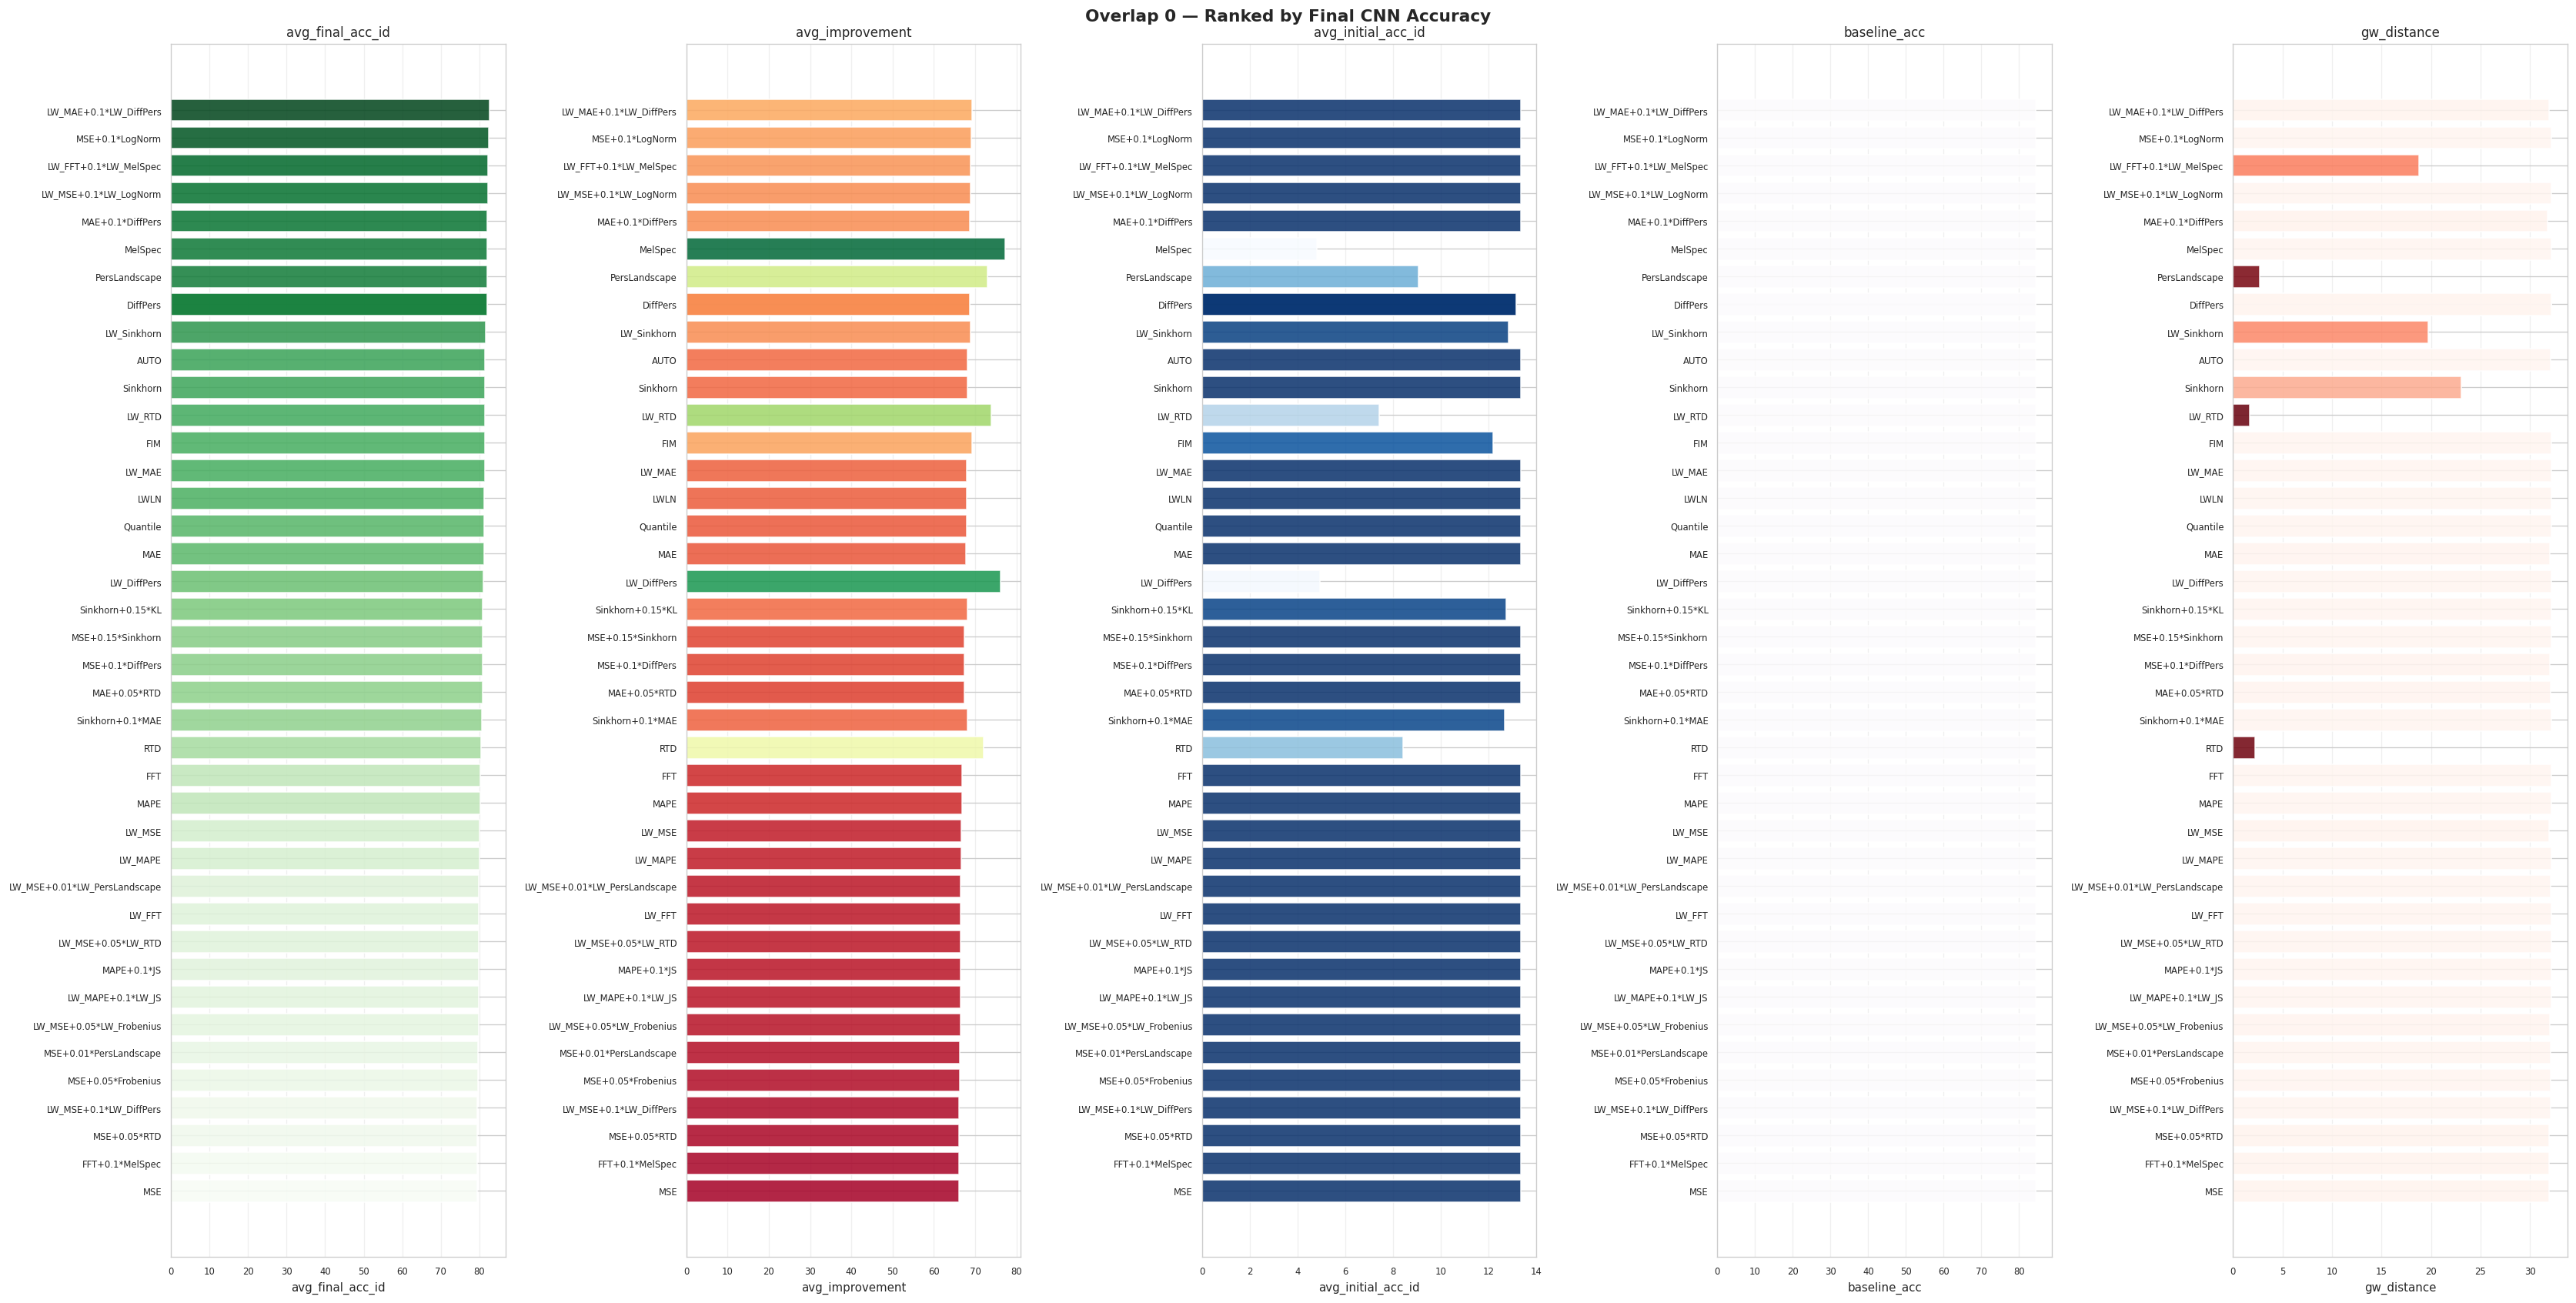

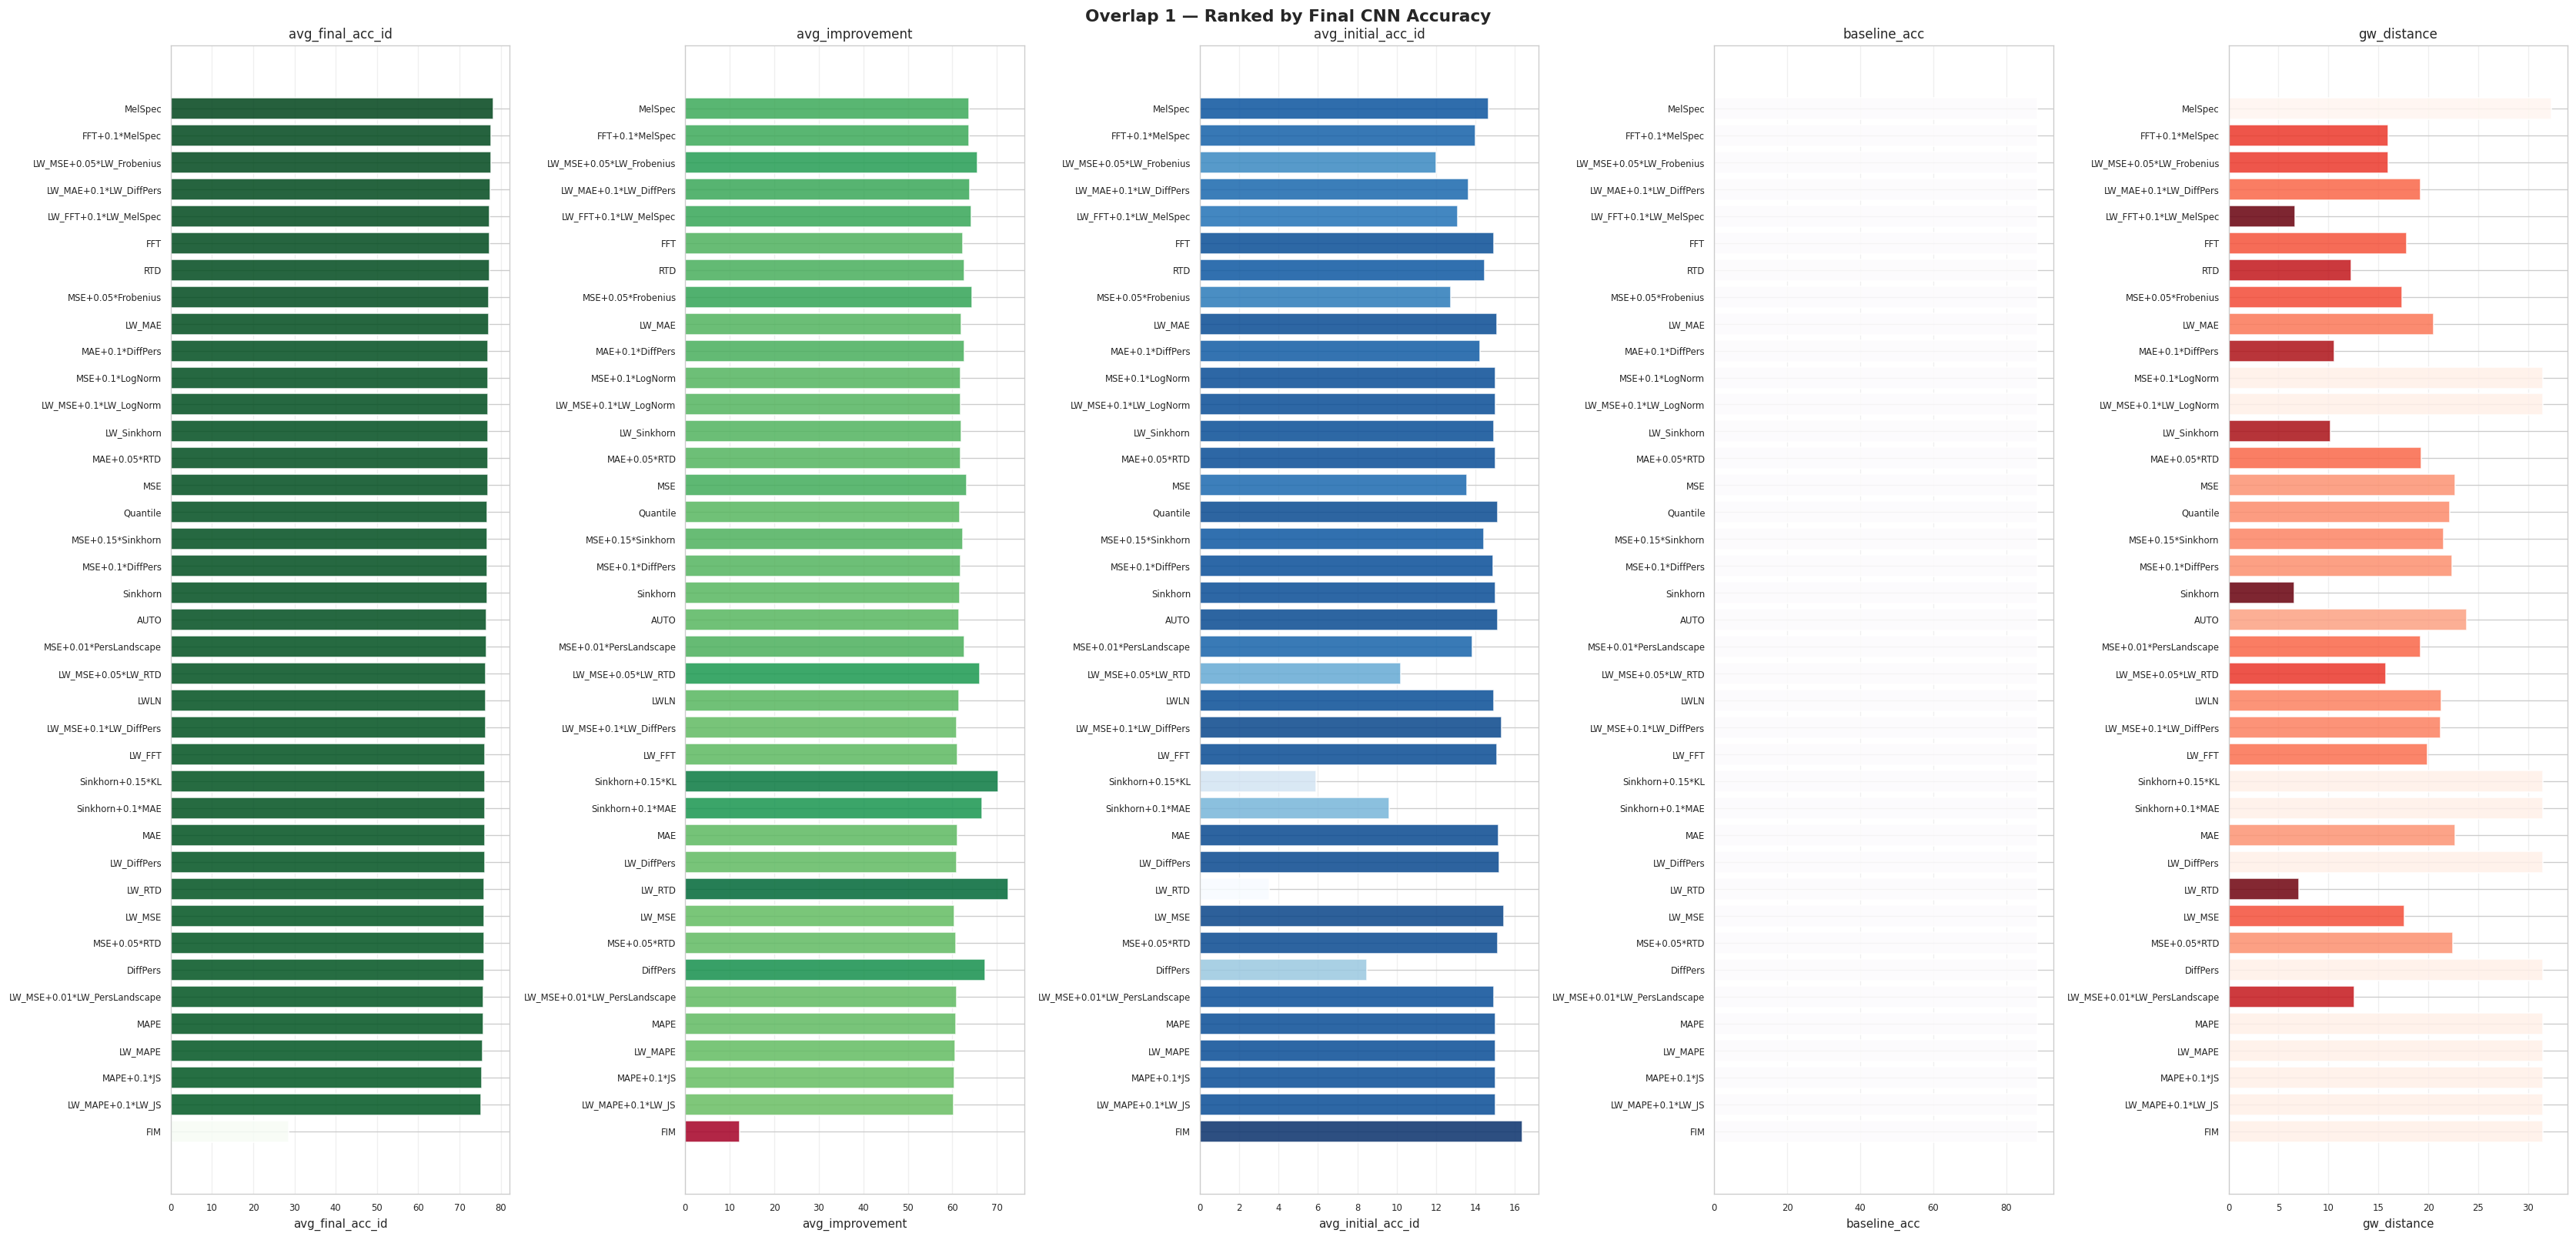

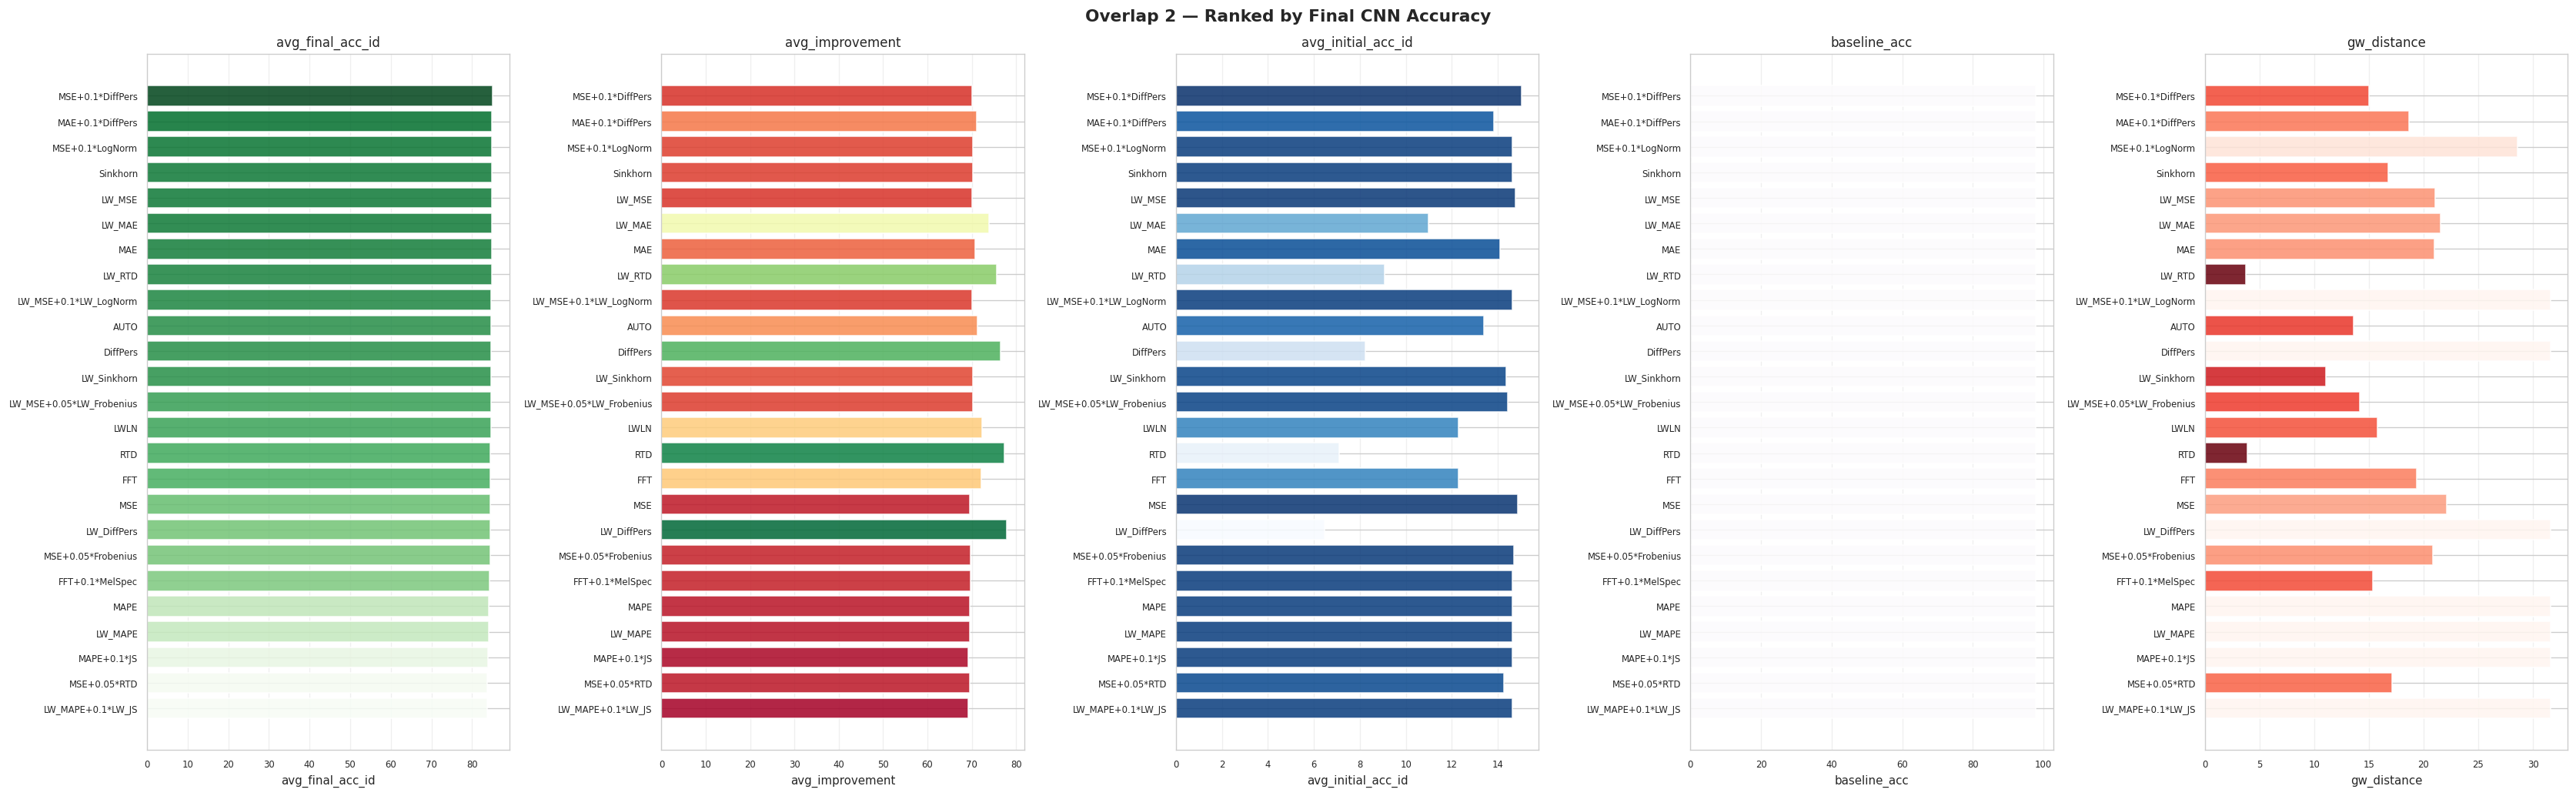

In [11]:
for ov in sorted(wandb_df['overlap'].unique()):
    sub = wandb_df[wandb_df['overlap'] == ov].sort_values('cnn/avg_final_acc_id', ascending=False)
    if sub.empty:
        continue
    
    fig, axes = plt.subplots(1, 5, figsize=(28, max(5, len(sub)*0.35)))
    plot_metrics = ['cnn/avg_final_acc_id', 'cnn/avg_improvement',
                    'cnn/avg_initial_acc_id', 'cnn/baseline_acc', 'topology/gw_distance']
    cmaps = ['Greens', 'RdYlGn', 'Blues', 'Purples', 'Reds_r']
    
    for ax, col, cm in zip(axes, plot_metrics, cmaps):
        vals = sub[col].fillna(0)
        norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-12)
        colors = plt.cm.get_cmap(cm)(norm.values)
        ax.barh(sub['loss_name'], vals, color=colors, alpha=0.85)
        ax.set_xlabel(col.split('/')[-1], fontsize=9)
        ax.set_title(col.split('/')[-1], fontsize=10)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        ax.tick_params(labelsize=7)
    
    plt.suptitle(f'Overlap {ov} — Ranked by Final CNN Accuracy', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(OUT / f'ranking_overlap{ov}.png', bbox_inches='tight', dpi=150)
    plt.show()

## 8. Master Table (all overlaps, all metrics)

In [12]:
# Pivot: one row per experiment, all metrics as columns
master = wandb_df[['run_name', 'overlap', 'loss_name'] + METRICS].copy()
master = master.sort_values(['overlap', 'cnn/avg_final_acc_id'], ascending=[True, False])
master = master.round(4)
master.to_csv(OUT / 'master_wandb_table.csv', index=False)

md = master.to_markdown(index=False)
with open(OUT / 'master_wandb_table.md', 'w') as f:
    f.write(f'# WandB Master Results Table\n\nSorted by overlap then final CNN accuracy (desc)\n\n{md}\n')

print(f'Master table: {master.shape}')
print(f'Saved to {OUT}')
master.head(10)

Master table: (105, 10)
Saved to /home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox/paper_results/zoo_eda


,run_name,overlap,loss_name,cnn/baseline_acc,cnn/avg_initial_acc_id,cnn/avg_final_acc_id,cnn/avg_improvement,topology/gw_distance,val_loss,train_loss
89,tiny_overlap0_LW_MAE_0.1xLW_DiffPers,0,LW_MAE+0.1*LW_DiffPers,84.5133,13.3407,82.5912,69.2506,31.9027,0.892852,0.878928
28,tiny_overlap0_MSE_0.1xLogNorm,0,MSE+0.1*LogNorm,84.5133,13.3407,82.4147,69.0740,32.1889,1.2581,1.241018
97,tiny_overlap0_LW_FFT_0.1xLW_MelSpec,0,LW_FFT+0.1*LW_MelSpec,84.5133,13.3407,82.2325,68.8919,18.7775,502.213164,489.337135
34,tiny_overlap0_LW_MSE_0.1xLW_LogNorm,0,LW_MSE+0.1*LW_LogNorm,84.5133,13.3407,82.1316,68.7909,32.1889,1.256494,1.240417
78,tiny_overlap0_MAE_0.1xDiffPers,0,MAE+0.1*DiffPers,84.5133,13.3407,82.0921,68.7514,31.7432,0.880153,0.867787
94,tiny_overlap0_MelSpec,0,MelSpec,84.5133,4.7996,82.0209,77.2213,32.1889,1.213498,1.204381
56,tiny_overlap0_PersLandscape,0,PersLandscape,84.5133,9.0670,81.9863,72.9192,2.6855,NaN,NaN
70,tiny_overlap0_DiffPers,0,DiffPers,84.5133,13.1501,81.9078,68.7577,32.1889,0.029839,0.030717
83,tiny_overlap0_DiffPers,0,DiffPers,84.5133,13.1501,81.9078,68.7577,32.1889,0.029839,0.030717
59,tiny_overlap0_LW_Sinkhorn,0,LW_Sinkhorn,84.5133,12.8359,81.6258,68.7899,19.7385,255.600672,231.421361


In [13]:
# Print summary of all saved files
print('\n=== All saved files ===')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB)')


=== All saved files ===
  digit_cooccurrence.png  (53.8 KB)
  master_wandb_table.csv  (12.2 KB)
  master_wandb_table.md  (25.5 KB)
  per_digit_label_sizes.png  (61.0 KB)
  ranking_overlap0.png  (239.2 KB)
  ranking_overlap1.png  (232.2 KB)
  ranking_overlap2.png  (154.2 KB)
  scenario_patterns.csv  (0.4 KB)
  scenario_task_sizes.png  (54.5 KB)
  table_cnn_avg_final_acc_id.csv  (4.8 KB)
  table_cnn_avg_final_acc_id.md  (9.7 KB)
  table_cnn_avg_improvement.csv  (4.8 KB)
  table_cnn_avg_improvement.md  (9.7 KB)
  table_cnn_avg_initial_acc_id.csv  (4.8 KB)
  table_cnn_avg_initial_acc_id.md  (9.7 KB)
  table_cnn_baseline_acc.csv  (4.9 KB)
  table_cnn_baseline_acc.md  (9.7 KB)
  table_topology_gw_distance.csv  (4.8 KB)
  table_topology_gw_distance.md  (9.7 KB)
  wandb_metrics.csv  (17.5 KB)
  zoo_accuracy.png  (72.1 KB)
  zoo_overview.png  (47.6 KB)
